In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  str    
 7   marital_status        593994 non-null  str    
 8   education_level       593994 non-null  str    
 9   employment_status     593994 non-null  str    
 10  loan_purpose          593994 non-null  str    
 11  grade_subgrade        593994 non-null  str    
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 84.0 MB


In [10]:
df_train['loan_paid_back'].value_counts(normalize=True)

loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [ ]:
# Detecting missing data
missing_data = df_test.isnull().sum()
missing_percent = (df_test.isnull().sum() / len(df_test)) * 100

print(missing_data)
print(missing_percent)

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64
id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
dtype: float64


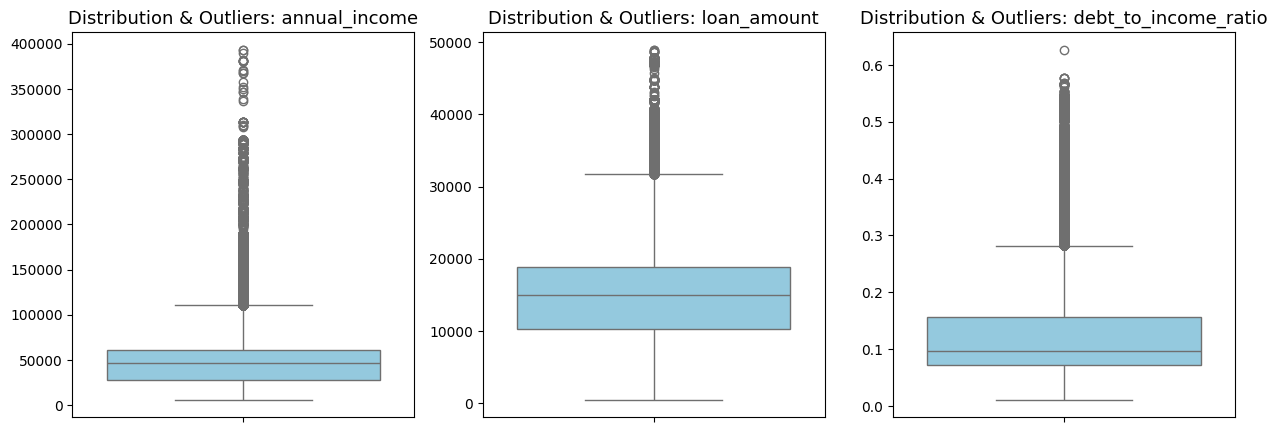

In [19]:
# Detecting outliers

cols_to_check = ['annual_income', 'loan_amount', 'debt_to_income_ratio']

plt.figure(figsize=(15,5))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col], color = 'skyblue')
    plt.title(f'Distribution & Outliers: {col}', fontsize=13)
    plt.ylabel('')

In [ ]:
df_clean = df_train

features_to_cap = ['annual_income', 'loan_amount', 'debt_to_income_ratio']

for col in features_to_cap:
    upper_limit = df_clean[col].quantile(0.99)

    df_clean[col] = np.clip(df_clean[col], a_min=None, a_max=upper_limit)

    print(f"Capped {col} at 99th percentile: {upper_limit:.2f}")

df_clean['annual_income_log']
np.log1p(df_clean['annual_income'])